In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os

import xarray
from scipy.signal import sweep_poly

from hdpgpc.get_data import compute_estimators_LDS
import math
from scipy.fft import fft
import h5py
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import wavespectra as wv
import xarray as xr
import importlib
import pickle
import hdpgpc.GPI_HDP as hdpgp
import re
from datetime import datetime, timedelta
import time

/home/adrian.perez/Documents/OceanWave/.venv/lib/python3.12/site-packages/xarray/backends/scipy_.py:39: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.io import netcdf_file as netcdf_file_base
/home/adrian.perez/Documents/OceanWave/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from hdpgpc.util_plots import print_results
import hdpgpc.util_plots as up
importlib.reload(up)
from hdpgpc.buoy_utils import interpolate_spectral_coefficients

---

### 1. Lectura de datos

In [3]:
cwd = os.path.dirname(os.getcwd())
data_path = os.path.join(cwd, 'data', 'ocean', 'wawaves')
f_hillary = h5py.File(os.path.join(data_path, 'Hillarys_202407.mat'),'r')
f_hillary_2 = h5py.File(os.path.join(data_path, 'Hillarys_202408.mat'),'r')
#f = h5py.File(os.path.join(data_path, 'TIDE_SouthAfricaDrifting03_202406.mat'),'r')
print(f_hillary.get('SpotData').keys())
direction = np.concatenate([np.array(f_hillary.get('SpotData/direction')), np.array(f_hillary_2.get('SpotData/direction'))], axis=1)
variance_density = np.concatenate([np.array(f_hillary.get('SpotData/varianceDensity')), np.array(f_hillary_2.get('SpotData/varianceDensity'))], axis=1)
spec_time_hillarys = np.concatenate([np.array(f_hillary.get('SpotData/spec_time')), np.array(f_hillary_2.get('SpotData/spec_time'))], axis=1)
time_hillarys = np.concatenate([np.array(f_hillary.get('SpotData/time')), np.array(f_hillary_2.get('SpotData/time'))], axis=1)
frequency_hillarys = np.concatenate([np.array(f_hillary.get('SpotData/frequency')), np.array(f_hillary_2.get('SpotData/frequency'))], axis=1)
dm_h = np.concatenate([np.array(f_hillary.get('SpotData/dm')), np.array(f_hillary_2.get('SpotData/dm'))], axis=1)
dp_h = np.concatenate([np.array(f_hillary.get('SpotData/dp')), np.array(f_hillary_2.get('SpotData/dp'))], axis=1)
a1 = np.concatenate([np.array(f_hillary.get('SpotData/a1')), np.array(f_hillary_2.get('SpotData/a1'))], axis=1)
a2 = np.concatenate([np.array(f_hillary.get('SpotData/a2')), np.array(f_hillary_2.get('SpotData/a2'))], axis=1)
b1 = np.concatenate([np.array(f_hillary.get('SpotData/b1')), np.array(f_hillary_2.get('SpotData/b1'))], axis=1)
b2 = np.concatenate([np.array(f_hillary.get('SpotData/b2')), np.array(f_hillary_2.get('SpotData/b2'))], axis=1)

print(variance_density.shape)
print(direction.shape)
print(a1.shape)
print(np.array(f_hillary.get('SpotData/dmspr')).shape)

from datetime import datetime, timedelta

def matlab_datenum_to_datetime(matlab_datenum):
    """
    Convert MATLAB datenum to Python datetime.
    """
    days = int(matlab_datenum)
    frac = matlab_datenum % 1
    python_datetime = datetime.fromordinal(days - 366) + timedelta(days=frac)
    return python_datetime

<KeysViewHDF5 ['a1', 'a2', 'b1', 'b2', 'bott_temp', 'df', 'direction', 'directionalSpread', 'dm', 'dm_sea', 'dm_swell', 'dmspr', 'dmspr_sea', 'dmspr_swell', 'dp', 'dpspr', 'endFreq_sea', 'endFreq_swell', 'frequency', 'hsig', 'hsig_sea', 'hsig_swell', 'lat', 'lon', 'name', 'part_time', 'press_std_time', 'press_time', 'pressure', 'pressure_std', 'qf_bott_temp', 'qf_sst', 'qf_waves', 'serialID', 'spec_time', 'startFreq_sea', 'startFreq_swell', 'surf_temp', 'temp_time', 'time', 'tm', 'tm_sea', 'tm_swell', 'tp', 'varianceDensity', 'wind_dir', 'wind_seasurfaceId', 'wind_speed', 'wind_time']>
(79, 2936)
(79, 2936)
(79, 2936)
(1, 744)


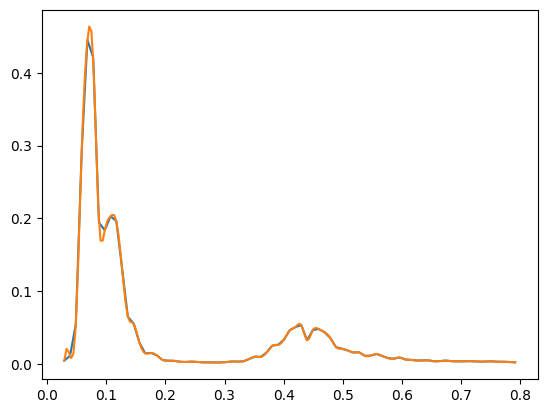

In [4]:
result = interpolate_spectral_coefficients(
    frequency_hillarys[:,0],
    variance_density,
    a1, b1, a2, b2,
    n_points=200,
    enforce_constraints=True
)
frequency_hillarys_dense = np.array([result['f_dense']]*frequency_hillarys.shape[1]).T
S_dense = result['variance_density_dense']
plt.plot(frequency_hillarys[:,0],variance_density[:,0])
plt.plot(frequency_hillarys_dense[:,0], S_dense[:,0])

frequency_hillarys = frequency_hillarys_dense
variance_density = S_dense
a1, b1, a2, b2 = result['a1_dense'], result['b1_dense'], result['a2_dense'], result['b2_dense']

In [5]:
startFreq_sea = np.array(f_hillary.get('SpotData/startFreq_sea'))[0][0]
startFreq_swell = np.array(f_hillary.get('SpotData/startFreq_swell'))[0][0]
print(frequency_hillarys.shape)

(200, 2936)


In [6]:
print("Shape of the data: ")
print(variance_density.shape)
num_obs_per_sample, num_samples  = variance_density.shape

Shape of the data: 
(200, 2936)


In [7]:
S_theta =  np.zeros((variance_density.shape[1], variance_density.shape[0], 37))
directions = np.deg2rad(np.linspace(0, 360.0, 37))
delta_theta = np.deg2rad(10.0)
for t in range(S_theta.shape[0]):
    for f in range(S_theta.shape[1]):
        # Load S(f), a1, b1, a2, b2 for this time and frequency
        S = variance_density[f, t]# Omnidirectional spectrum
        a1_, b1_, a2_, b2_ = a1[f,t], b1[f,t], a2[f,t], b2[f,t]  # Directional moments

        for i, theta in enumerate(directions):
            # Compute D(f, theta)
            D = (1 / 2 * np.pi) * (
                    1 + (a1_ * np.cos(theta) + b1_ * np.sin(theta))
                    + (a2_ * np.cos(2 * theta) + b2_ * np.sin(2 * theta))
            )

            # Ensure non-negativity
            D = max(D, 0)

            # Compute S(f, theta)
            S_theta[t, f, i] = S * D

        # Optional: Renormalize to ensure sum(S_theta * delta_theta) ≈ S
        integral = np.sum(S_theta[t, f, :]) * delta_theta
        integral = integral if integral > 0 else 1.0
        S_theta[t, f, :] *= S / integral  # Adjust if integral != S

In [8]:
from scipy.interpolate import interp1d
from datetime import datetime, timedelta
import hdpgpc.buoy_utils as buoy_utils

dirs = np.linspace(0, 360.0, 37)
dirs_rad= np.deg2rad(dirs)

#ind_ = 0
S_theta_rotated = np.zeros_like(S_theta)

for ind_ in range(0, num_samples, 1):
    time_h = matlab_datenum_to_datetime(spec_time_hillarys[:, ind_].item())
    ind_dp = np.argmin(np.abs(time_hillarys - spec_time_hillarys[:, ind_]))
    error_mean_, error_peak_ = buoy_utils.compute_rotation_deviation(S_theta[ind_], dirs, a1[:,ind_], b1[:,ind_], dm_h[:,ind_dp], dp_h[:,ind_dp])
    error = -np.mean([error_mean_, error_peak_])
    dirs_rotated = (dirs + error) % 360.0
    f_interp = interp1d(
        dirs,
        S_theta[ind_,:,:],
        kind='linear', # 'cubic' is smoother but can overshoot negatively
        axis=-1,       # Interpolate along direction axis
        assume_sorted=True
    )
    #indexes_directions_new = np.floor(dirs_rotated // 10).astype(np.int32)
    S_theta_rotated[ind_, :, :] = f_interp(dirs_rotated)

dataset = xr.Dataset(
    data_vars=dict(
        efth=(["time", "freq", "dir"], S_theta_rotated)
    ),
    coords=dict(
        time=(["time"], spec_time_hillarys[0]),
        freq=(["freq"], frequency_hillarys[:,0]),
        dir=(["dir"], dirs)
    )
)
dts_hillarys = wv.SpecDataset(dataset)
new_dirs = np.linspace(0, 360, 37)# Cada 10° incluyendo 360°
directions_hillarys = new_dirs
rotated_dirs = (180 + new_dirs) % 360
data_ = dts_hillarys.interp(dir=rotated_dirs)
frequency_hillarys = frequency_hillarys[:, 0]
freq = data_.freq
freq_hillarys = data_.freq


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm


def plot_directional_spectrum(frequencies, directions, spectrum,
                                     title='Directional Wave Spectrum',
                                     vmax=None, vmin=None, cmap='jet', colorbar=True):
    """
    Plot directional wave spectrum with smooth gradient colors.

    Uses pcolormesh for continuous color gradients without banding.

    Parameters:
    -----------
    frequencies : np.ndarray
        Frequency array (Hz), shape (nf,)
    directions : np.ndarray
        Direction array (degrees, nautical convention), shape (nd,)
    spectrum : np.ndarray
        2D directional spectrum E(f,θ), shape (nf, nd)
    title : str
        Plot title
    vmax : float, optional
        Maximum value for colorbar
    vmin : float, optional
        Minimum value for colorbar
    cmap : str
        Colormap name (default: 'jet')
    """
    # Convert directions to radians (nautical convention)
    theta = np.radians(90 - directions)

    # Close the circle for seamless wrapping at 360°/0°
    theta_closed = np.append(theta, theta[0] + 2 * np.pi)
    spectrum_closed = np.column_stack([spectrum, spectrum[:, 0]])

    # Create meshgrid
    THETA, FREQ = np.meshgrid(theta_closed, frequencies)

    # Create polar plot
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

    # Auto-scale if not provided
    if vmax is None:
        vmax = np.percentile(spectrum, 95)
    if vmin is None:
        vmin = 0  # Typically 0 for wave spectra

    # Pcolormesh for smooth gradients (no banding!)
    mesh = ax.pcolormesh(THETA, FREQ, spectrum_closed,
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         shading='auto',  # Smooth interpolation
                         rasterized=True)  # Better rendering

    # Customize appearance
    ax.set_theta_zero_location('N')  # North at top
    ax.set_theta_direction(-1)  # Clockwise (nautical convention)

    # Add colorbar
    if colorbar:
        cbar = plt.colorbar(mesh, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Energy Density (m²/Hz/deg)', rotation=270, labelpad=20, fontsize=16)

    # Add title
    ax.set_title(title, pad=20, fontsize=14, fontweight='bold')

    # Radial axis label

    #ax.set_zlabel('Frequency (Hz)', labelpad=30, fontsize=16)
    #ax.set_ylabel('Direction (degrees)', labelpad=20, fontsize=16)
    ax.tick_params(labelsize=20)
    plt.tight_layout()
    return fig, ax

Time event
2024-08-02 00:00:00
1519


/tmp/ipykernel_295169/1508110118.py:51: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.



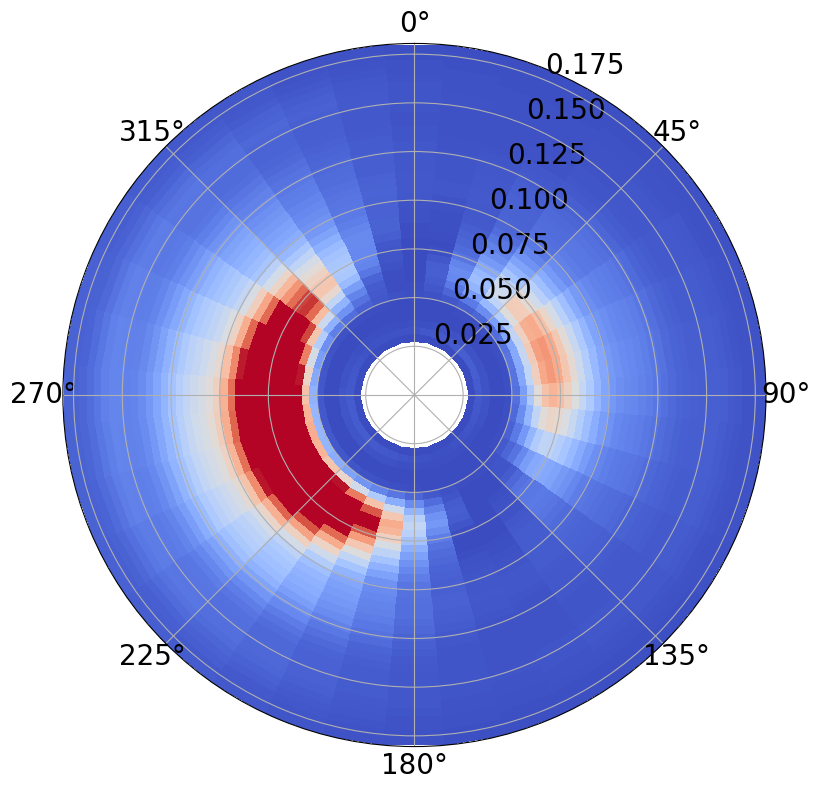

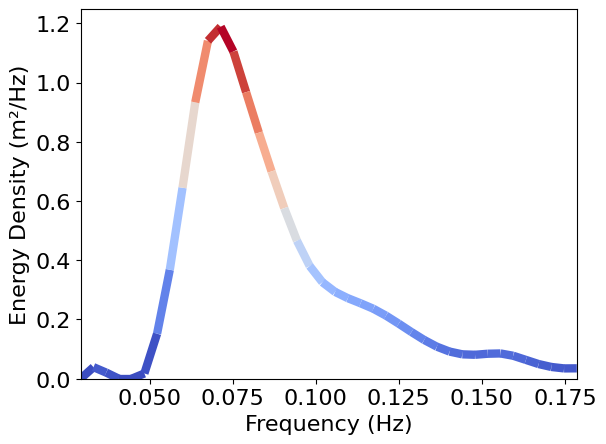

In [26]:
time_select_datetime = datetime(2024, 8, 2, 0)
time_select_ordinal = datetime.toordinal(time_select_datetime + timedelta(days = 366))
index_hillary = np.argmin(np.abs(spec_time_hillarys - time_select_ordinal))
print("Time event")
print(time_select_datetime)
print(index_hillary)
fig, ax = plot_directional_spectrum(freq[:40], directions_hillarys, data_[index_hillary,:40,:],
                                        title='', cmap='coolwarm', colorbar=False)
plt.savefig("Directional_spectra_no_colorbar.pdf")


import numpy as np
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors

cmap = mpl.colormaps["coolwarm"]          # or "coolwarm", etc.
vmin, vmax = 0.0, np.max(np.mean(data_[index_hillary,:40,:], axis=1)) # choose consistently across both plots
norm = colors.Normalize(vmin=vmin, vmax=vmax)
pts = np.array([freq[:40], np.mean(data_[index_hillary,:40,:], axis=1)]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

col = cmap(norm(vmax))
fig, ax_1d = plt.subplots()

#ax_1d.plot(freq[:40], np.mean(data_[index_hillary,:40,:], axis=1), color=col, lw=2)
#ax_1d.fill_between(freq[:40], 0, np.mean(data_[index_hillary,:40,:], axis=1), color=col, alpha=0.25)
lc = LineCollection(segs, cmap=cmap, norm=norm)
lc.set_array(np.mean(data_[index_hillary,:40,:], axis=1)[:-1])     # color by energy
lc.set_linewidth(6)

ax_1d.add_collection(lc)
ax_1d.set_xlim(freq[:40].min(), freq[:40].max())
ax_1d.set_ylim(0, np.mean(data_[index_hillary,:40,:], axis=1).max()*1.05)
plt.ylabel("Energy Density (m²/Hz)", fontsize=16)
plt.xlabel("Frequency (Hz)", fontsize=16)
ax_1d.tick_params(labelsize=16)
plt.savefig("Standard_spectra.pdf")

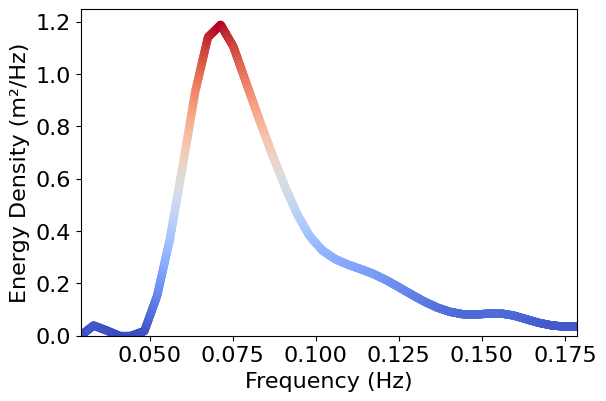

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib import colors

y = np.mean(data_[index_hillary, :40, :], axis=1)
x = np.asarray(freq[:40])

# --- upsample to hide segmentation ---
N = 1200
x2 = np.linspace(np.min(x), np.max(x), N)
y2 = np.interp(x2, x, y)  # or spline if you want smoother curvature

cmap = mpl.colormaps["coolwarm"]
vmin, vmax = 0.0, y.max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)

# build segments
pts = np.column_stack([x2, y2]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

lc = LineCollection(
    segs,
    cmap=cmap,
    norm=norm,
    antialiased=True,
    capstyle="round",
    joinstyle="round",
)
lc.set_array(y2[:-1])
lc.set_linewidth(6)

fig, ax = plt.subplots()
ax.add_collection(lc)
ax.set_xlim(x2.min(), x2.max())
ax.set_ylim(0, y2.max() * 1.05)
plt.ylabel("Energy Density (m²/Hz)", fontsize=16)
plt.xlabel("Frequency (Hz)", fontsize=16)
ax.tick_params(labelsize=16)
lc.set_rasterized(True)
plt.subplots_adjust(bottom=0.2)
plt.savefig("Standard_spectra_dense.pdf", dpi=300)  # adjust dpi as desired



In [89]:
# data_shoal = np.load("/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/data/ocean/wawaves/Hillarys_0708_shoaled.npy")
# print(data_shoal.shape)
# data = data_shoal
data = data_.to_numpy()
freq_ = np.array(freq)

Shape of hs: (2936, 1)
How much spectra falls in the range 0.5-1.5 Hs: 2936


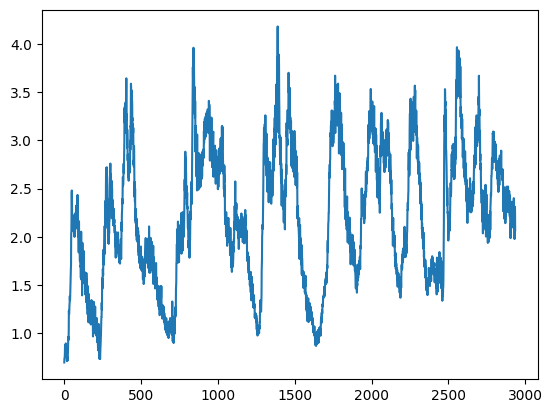

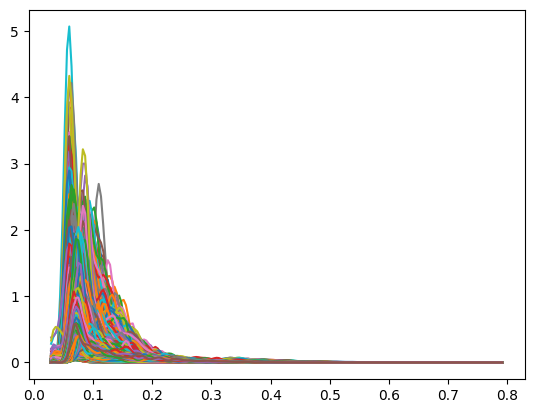

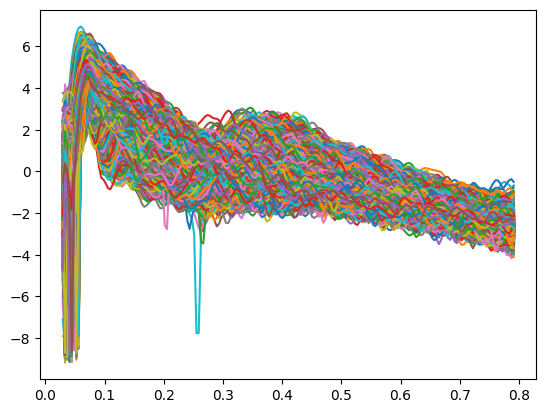

In [90]:
 #Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq_[1]-freq_[0], num_obs_per_sample)[:, np.newaxis]
hs_h = 4 * np.sqrt(np.sum(data, axis=2) * delta_theta @ interv)
print("Shape of hs: "+str(hs_h.shape))
plt.plot(hs_h)
chosen_indexes = np.where((hs_h > 0.5) & (hs_h < 1.5))[0]
chosen_indexes = np.arange(num_samples)
print("How much spectra falls in the range 0.5-1.5 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data[:,:,0][chosen_indexes].T)
plt.show()
lognorm_data = np.log(data + 1e-6) - np.mean(np.log(data+ 1e-6), axis=1)[:,np.newaxis,:]
plt.plot(freq, lognorm_data[:,:,0][chosen_indexes].T)
plt.show()


### Se cogen solo los datos de un año natural

In [91]:
#Select indexes
data = data[chosen_indexes]
print("Shape of the data: ")
print(data.shape)

num_samples, num_obs_per_sample, num_outputs = data.shape

Shape of the data: 
(2936, 200, 37)


In [92]:

# x_basis has to have the same dimension structure as data[0], in this case (171,1) but it could be (n_inducing_points, 1).
lim_freq = startFreq_sea
index_freq = np.where(freq>lim_freq)[0][0]+1


In [93]:

cluster_labels_h = np.load('/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/cluster_labels/resampled_low_freq/cluster_labels_hillary_202407_dynamic_5.npy')


Now with drifting 03.

<KeysViewHDF5 ['a1', 'a2', 'b1', 'b2', 'bott_temp', 'df', 'direction', 'directionalSpread', 'dm', 'dm_sea', 'dm_swell', 'dmspr', 'dmspr_sea', 'dmspr_swell', 'dp', 'dpspr', 'endFreq_sea', 'endFreq_swell', 'frequency', 'hsig', 'hsig_sea', 'hsig_swell', 'lat', 'lon', 'name', 'part_time', 'press_std_time', 'press_time', 'pressure', 'pressure_std', 'qf_bott_temp', 'qf_sst', 'qf_waves', 'serialID', 'spec_time', 'startFreq_sea', 'startFreq_swell', 'surf_temp', 'temp_time', 'time', 'tm', 'tm_sea', 'tm_swell', 'tp', 'varianceDensity', 'wind_dir', 'wind_seasurfaceId', 'wind_speed', 'wind_time']>
Shape of the data: 
(39, 645)


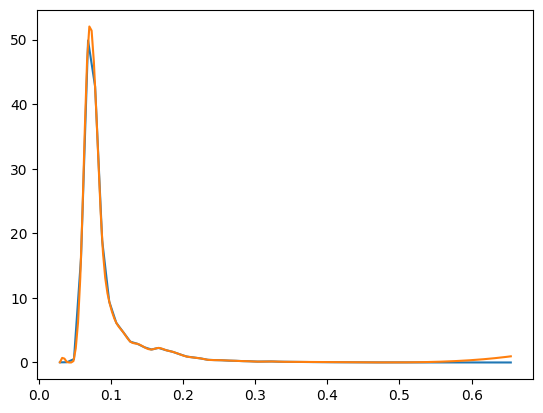

In [94]:

cwd = os.path.dirname(os.getcwd())
data_path = os.path.join(cwd, 'data', 'ocean', 'wawaves')
#f = h5py.File(os.path.join(data_path, 'Hillarys_202405.mat'), 'r')
f_drift03 = h5py.File(os.path.join(data_path, 'TIDE_SouthAfricaDrifting03_202407.mat'),'r')
f_drift03_2 = h5py.File(os.path.join(data_path, 'TIDE_SouthAfricaDrifting03_202408.mat'),'r')
print(f_drift03.get('SpotData').keys())
direction = np.concatenate([np.array(f_drift03.get('SpotData/direction')), np.array(f_drift03_2.get('SpotData/direction'))], axis=1)
variance_density = np.concatenate([np.array(f_drift03.get('SpotData/varianceDensity')), np.array(f_drift03_2.get('SpotData/varianceDensity'))], axis=1)
spec_time_drift03 = np.concatenate([np.array(f_drift03.get('SpotData/spec_time')), np.array(f_drift03_2.get('SpotData/spec_time'))], axis=1)
time_drift03 = np.concatenate([np.array(f_drift03.get('SpotData/time')), np.array(f_drift03_2.get('SpotData/time'))], axis=1)
frequency = np.concatenate([np.array(f_drift03.get('SpotData/frequency')), np.array(f_drift03_2.get('SpotData/frequency'))], axis=1)
dm_d03 = np.concatenate([np.array(f_drift03.get('SpotData/dm')), np.array(f_drift03_2.get('SpotData/dm'))], axis=1)
dp_d03 = np.concatenate([np.array(f_drift03.get('SpotData/dp')), np.array(f_drift03_2.get('SpotData/dp'))], axis=1)
a1 = np.concatenate([np.array(f_drift03.get('SpotData/a1')), np.array(f_drift03_2.get('SpotData/a1'))], axis=1)
a2 = np.concatenate([np.array(f_drift03.get('SpotData/a2')), np.array(f_drift03_2.get('SpotData/a2'))], axis=1)
b1 = np.concatenate([np.array(f_drift03.get('SpotData/b1')), np.array(f_drift03_2.get('SpotData/b1'))], axis=1)
b2 = np.concatenate([np.array(f_drift03.get('SpotData/b2')), np.array(f_drift03_2.get('SpotData/b2'))], axis=1)
print("Shape of the data: ")
print(variance_density.shape)

result = interpolate_spectral_coefficients(
    frequency[:,0],
    variance_density,
    a1, b1, a2, b2,
    n_points=200,
    enforce_constraints=True
)
frequency_drift03_dense = np.array([result['f_dense']]*frequency.shape[1]).T
S_dense = result['variance_density_dense']
plt.plot(frequency[:,0],variance_density[:,0])
plt.plot(frequency_drift03_dense[:,0], S_dense[:,0])

frequency_drift03 = frequency_drift03_dense[:, 0]
variance_density = S_dense
a1, b1, a2, b2 = result['a1_dense'], result['b1_dense'], result['a2_dense'], result['b2_dense']


In [95]:
num_obs_per_sample, num_samples = variance_density.shape
S_theta = np.zeros((variance_density.shape[1], variance_density.shape[0], 37))
directions = np.deg2rad(np.linspace(0, 360.0, 37))
delta_theta = np.deg2rad(10.0)

In [96]:
for t in range(S_theta.shape[0]):
    for f in range(S_theta.shape[1]):
        # Load S(f), a1, b1, a2, b2 for this time and frequency
        S = variance_density[f, t]  # Omnidirectional spectrum
        a1_, b1_, a2_, b2_ = a1[f, t], b1[f, t], a2[f, t], b2[f, t]  # Directional moments
        if a1_ == -9999.0:
            a1_, b1_, a2_, b2_ = 0.0, 0.0, 0.0, 0.0
        for i, theta in enumerate(directions):
            # Compute D(f, theta)
            D = (1 / 2 * np.pi) * (
                    1 + (a1_ * np.cos(theta) + b1_ * np.sin(theta))
                    + (a2_ * np.cos(2 * theta) + b2_ * np.sin(2 * theta))
            )

            # Ensure non-negativity
            D = max(D, 0)

            # Compute S(f, theta)
            S_theta[t, f, i] = S * D

        # Optional: Renormalize to ensure sum(S_theta * delta_theta) ≈ S
        integral = np.sum(S_theta[t, f, :]) * delta_theta
        integral = integral if integral > 0 else 1.0
        S_theta[t, f, :] *= S / integral  # Adjust if integral != S


In [97]:
import hdpgpc.buoy_utils as buoy_utils
dirs = np.linspace(0, 360.0, 37)
dirs_rad= np.deg2rad(dirs)

#ind_ = 0
S_theta_rotated = np.zeros_like(S_theta)

for ind_ in range(0, num_samples, 1):
    time_h = matlab_datenum_to_datetime(spec_time_drift03[:, ind_].item())
    ind_dp = np.argmin(np.abs(time_drift03 - spec_time_drift03[:, ind_]))
    error_mean_, error_peak_ = buoy_utils.compute_rotation_deviation(S_theta[ind_], dirs, a1[:,ind_], b1[:,ind_], dm_d03[:,ind_dp], dp_d03[:,ind_dp])
    error = -np.mean([error_mean_, error_peak_])
    dirs_rotated = (dirs + error) % 360.0
    f_interp = interp1d(
        dirs,
        S_theta[ind_,:,:],
        kind='linear', # 'cubic' is smoother but can overshoot negatively
        axis=-1,       # Interpolate along direction axis
        assume_sorted=True
    )
    #indexes_directions_new = np.floor(dirs_rotated // 10).astype(np.int32)
    S_theta_rotated[ind_, :, :] = f_interp(dirs_rotated)

dataset = xr.Dataset(
    data_vars=dict(
        efth=(["time", "freq", "dir"], S_theta_rotated)
    ),
    coords=dict(
        time=(["time"], spec_time_drift03[0]),
        freq=(["freq"], frequency_drift03),
        dir=(["dir"], dirs)
    )
)
dts_drift03 = wv.SpecDataset(dataset)
new_dirs = np.linspace(0, 360, 37)  # Cada 10° incluyendo 360°
rotated_dirs = (180 + new_dirs) % 360
data_drifting03 = dts_drift03.interp(dir=rotated_dirs)
freq = data_drifting03.freq
data_drifting03 = data_drifting03.to_numpy()
freq_ = np.array(freq)

(645, 200, 37)
(200, 1)
Shape of hs: (645, 1)
How much spectra falls in the range 0.5-1.5 Hs: 645


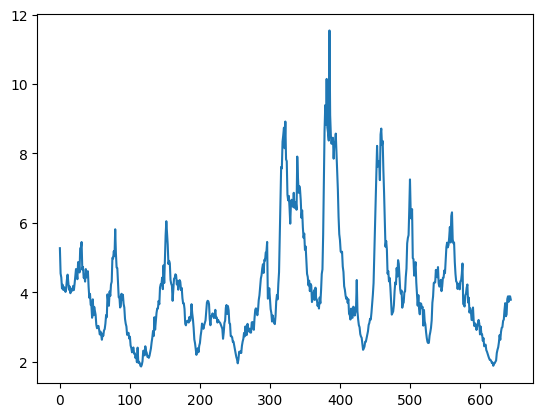

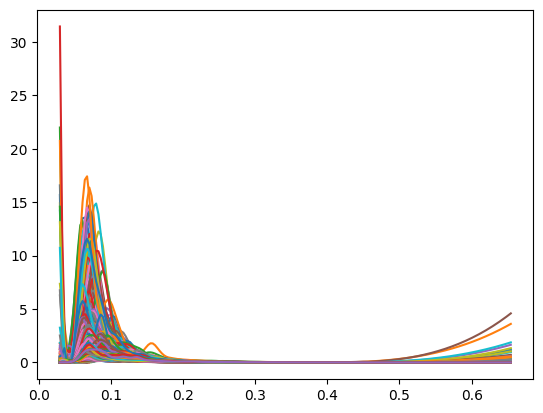

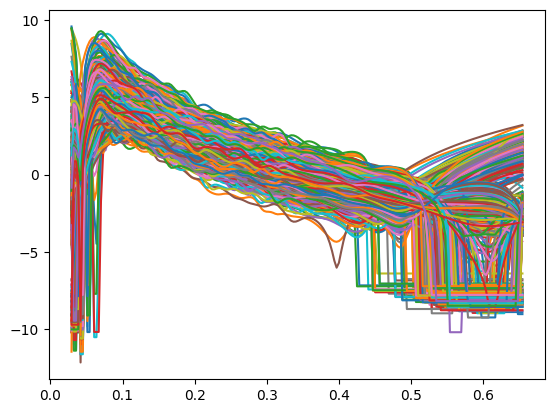

In [98]:
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq_[1] - freq_[0], num_obs_per_sample)[:, np.newaxis]
print(data_drifting03.shape)
print(interv.shape)
hs_d03 = 4 * np.sqrt(np.sum(data_drifting03, axis=2) * delta_theta @ interv)
print("Shape of hs: " + str(hs_d03.shape))
plt.plot(hs_d03)
chosen_indexes = np.where((hs_d03 > 0.5) & (hs_d03 < 1.5))[0]
chosen_indexes = np.arange(num_samples)
print("How much spectra falls in the range 0.5-1.5 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data_drifting03[:, :, 0][chosen_indexes].T)
plt.show()
lognorm_data = np.log(data_drifting03 + 1e-6) - np.mean(np.log(data_drifting03 + 1e-6), axis=1)[:, np.newaxis, :]
plt.plot(freq, lognorm_data[:, :, 0][chosen_indexes].T)
plt.show()

In [99]:
data_drifting03 = data_drifting03[chosen_indexes]
print("Shape of the data: ")
print(data_drifting03.shape)

lim_freq = startFreq_sea
index_freq = np.where(freq>lim_freq)[0][0]+1


Shape of the data: 
(645, 200, 37)


In [100]:

cluster_labels_d03 = np.load('/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/cluster_labels/resampled_low_freq/cluster_labels_drift03_202407_dynamic_9.npy')


Now with drifting 06.

<KeysViewHDF5 ['a1', 'a2', 'b1', 'b2', 'bott_temp', 'df', 'direction', 'directionalSpread', 'dm', 'dm_sea', 'dm_swell', 'dmspr', 'dmspr_sea', 'dmspr_swell', 'dp', 'dpspr', 'endFreq_sea', 'endFreq_swell', 'frequency', 'hsig', 'hsig_sea', 'hsig_swell', 'lat', 'lon', 'name', 'part_time', 'press_std_time', 'press_time', 'pressure', 'pressure_std', 'qf_bott_temp', 'qf_sst', 'qf_waves', 'serialID', 'spec_time', 'startFreq_sea', 'startFreq_swell', 'surf_temp', 'temp_time', 'time', 'tm', 'tm_sea', 'tm_swell', 'tp', 'varianceDensity', 'wind_dir', 'wind_seasurfaceId', 'wind_speed', 'wind_time']>
Shape of the data: 
(39, 747)


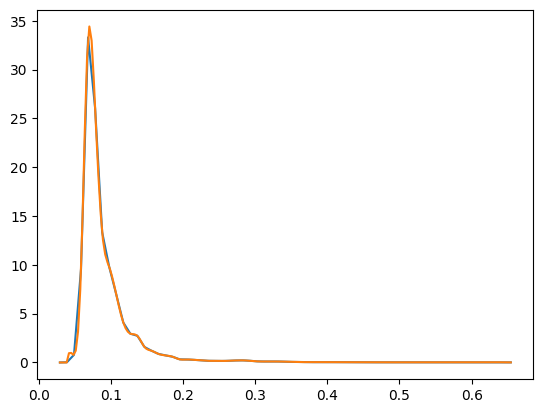

In [101]:

cwd = os.path.dirname(os.getcwd())
data_path = os.path.join(cwd, 'data', 'ocean', 'wawaves')
#f = h5py.File(os.path.join(data_path, 'Hillarys_202405.mat'), 'r')
f_drift06 = h5py.File(os.path.join(data_path, 'TIDE_SouthAfricaDrifting08_202407.mat'), 'r')
f_drift06_2 = h5py.File(os.path.join(data_path, 'TIDE_SouthAfricaDrifting08_202408.mat'), 'r')
print(f_drift06.get('SpotData').keys())
direction = np.concatenate([np.array(f_drift06.get('SpotData/direction')), np.array(f_drift06_2.get('SpotData/direction'))], axis=1)
variance_density = np.concatenate([np.array(f_drift06.get('SpotData/varianceDensity')), np.array(f_drift06_2.get('SpotData/varianceDensity'))], axis=1)
spec_time_drift06 = np.concatenate([np.array(f_drift06.get('SpotData/spec_time')), np.array(f_drift06_2.get('SpotData/spec_time'))], axis=1)
time_drift06 = np.concatenate([np.array(f_drift06.get('SpotData/time')), np.array(f_drift06_2.get('SpotData/time'))], axis=1)
frequency = np.concatenate([np.array(f_drift06.get('SpotData/frequency')), np.array(f_drift06_2.get('SpotData/frequency'))], axis=1)
dm_d06 = np.concatenate([np.array(f_drift06.get('SpotData/dm')), np.array(f_drift06_2.get('SpotData/dm'))], axis=1)
dp_d06 = np.concatenate([np.array(f_drift06.get('SpotData/dp')), np.array(f_drift06_2.get('SpotData/dp'))], axis=1)
a1 = np.concatenate([np.array(f_drift06.get('SpotData/a1')), np.array(f_drift06_2.get('SpotData/a1'))], axis=1)
a2 = np.concatenate([np.array(f_drift06.get('SpotData/a2')), np.array(f_drift06_2.get('SpotData/a2'))], axis=1)
b1 = np.concatenate([np.array(f_drift06.get('SpotData/b1')), np.array(f_drift06_2.get('SpotData/b1'))], axis=1)
b2 = np.concatenate([np.array(f_drift06.get('SpotData/b2')), np.array(f_drift06_2.get('SpotData/b2'))], axis=1)
print("Shape of the data: ")
print(variance_density.shape)

result = interpolate_spectral_coefficients(
    frequency[:,0],
    variance_density,
    a1, b1, a2, b2,
    n_points=200,
    enforce_constraints=True
)
frequency_drift06_dense = np.array([result['f_dense']]*frequency.shape[1]).T
S_dense = result['variance_density_dense']
plt.plot(frequency[:,0],variance_density[:,0])
plt.plot(frequency_drift06_dense[:,0], S_dense[:,0])

frequency_drift06 = frequency_drift06_dense[:,0]
variance_density = S_dense
a1, b1, a2, b2 = result['a1_dense'], result['b1_dense'], result['a2_dense'], result['b2_dense']

In [102]:

num_obs_per_sample, num_samples = variance_density.shape
S_theta = np.zeros((variance_density.shape[1], variance_density.shape[0], 37))
directions = np.deg2rad(np.linspace(0, 360.0, 37))
delta_theta = np.deg2rad(10.0)
for t in range(S_theta.shape[0]):
    for f in range(S_theta.shape[1]):
        # Load S(f), a1, b1, a2, b2 for this time and frequency
        S = variance_density[f, t]  # Omnidirectional spectrum
        a1_, b1_, a2_, b2_ = a1[f, t], b1[f, t], a2[f, t], b2[f, t]  # Directional moments

        for i, theta in enumerate(directions):
            # Compute D(f, theta)
            D = (1 / 2 * np.pi) * (
                    1 + (a1_ * np.cos(theta) + b1_ * np.sin(theta))
                    + (a2_ * np.cos(2 * theta) + b2_ * np.sin(2 * theta))
            )

            # Ensure non-negativity
            D = max(D, 0)

            # Compute S(f, theta)
            S_theta[t, f, i] = S * D

        # Optional: Renormalize to ensure sum(S_theta * delta_theta) ≈ S
        integral = np.sum(S_theta[t, f, :]) * delta_theta
        integral = integral if integral > 0 else 1.0
        S_theta[t, f, :] *= S / integral  # Adjust if integral != S

Shape of hs: (747, 1)
How much spectra falls in the range 0.5-1.5 Hs: 747


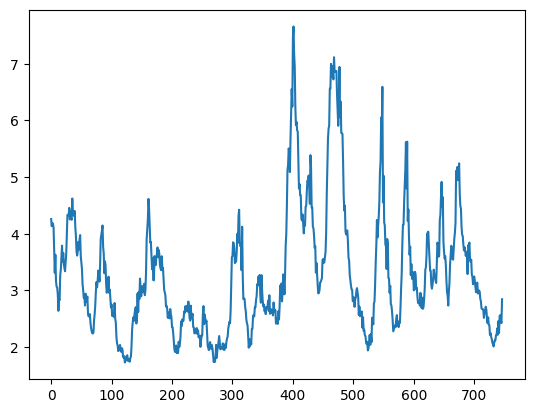

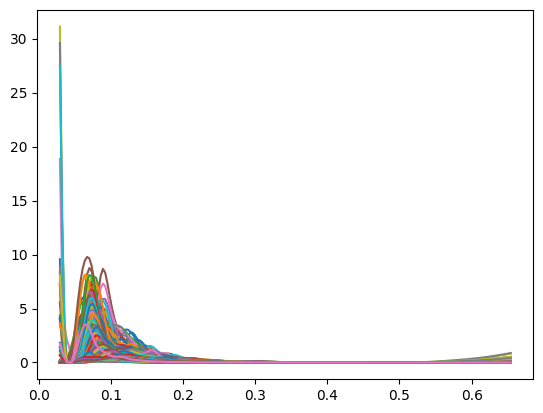

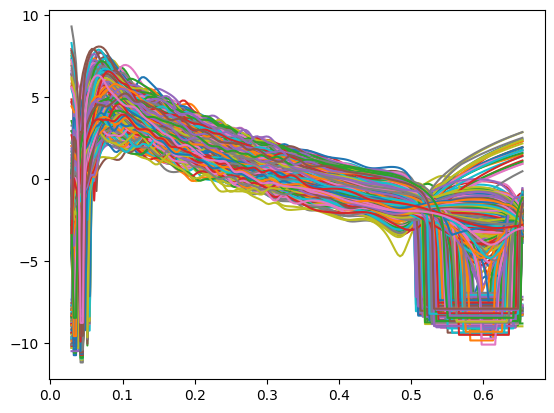

Shape of the data: 
(747, 200, 37)


In [103]:
import hdpgpc.buoy_utils as buoy_utils

dirs = np.linspace(0, 360.0, 37)
dirs_rad= np.deg2rad(dirs)

#ind_ = 0
S_theta_rotated = np.zeros_like(S_theta)

for ind_ in range(0, num_samples, 1):
    time_h = matlab_datenum_to_datetime(spec_time_hillarys[:, ind_].item())
    ind_dp = np.argmin(np.abs(time_hillarys - spec_time_hillarys[:, ind_]))
    error_mean_, error_peak_ = buoy_utils.compute_rotation_deviation(S_theta[ind_], dirs, a1[:,ind_], b1[:,ind_], dm_h[:,ind_dp], dp_h[:,ind_dp])
    error = -np.mean([error_mean_, error_peak_])
    dirs_rotated = (dirs + error) % 360.0
    f_interp = interp1d(
        dirs,
        S_theta[ind_,:,:],
        kind='linear', # 'cubic' is smoother but can overshoot negatively
        axis=-1,       # Interpolate along direction axis
        assume_sorted=True
    )
    #indexes_directions_new = np.floor(dirs_rotated // 10).astype(np.int32)
    S_theta_rotated[ind_, :, :] = f_interp(dirs_rotated)

dataset = xr.Dataset(
    data_vars=dict(
        efth=(["time", "freq", "dir"], S_theta_rotated)
    ),
    coords=dict(
        time=(["time"], spec_time_drift06[0]),
        freq=(["freq"], frequency_drift06),
        dir=(["dir"], dirs)
    )
)
dts_drift06 = wv.SpecDataset(dataset)
new_dirs = np.linspace(0, 360, 37) # Cada 10° incluyendo 360°
rotated_dirs = (180 + new_dirs) % 360.0
data_drifting06 = dts_drift06.interp(dir=rotated_dirs)
freq = data_drifting06.freq
data_drifting06 = data_drifting06.to_numpy()
freq_ = np.array(freq)
#Here we are going to compute the Heighs and try to filter following Hamiltons rule.
interv = np.repeat(freq_[1] - freq_[0], num_obs_per_sample)[:, np.newaxis]
hs_d06 = 4 * np.sqrt(np.sum(data_drifting06, axis=2) * delta_theta @ interv)
print("Shape of hs: " + str(hs_d06.shape))
plt.plot(hs_d06)
chosen_indexes = np.where((hs_d06 > 0.5) & (hs_d06 < 1.5))[0]
chosen_indexes = np.arange(num_samples)
print("How much spectra falls in the range 0.5-1.5 Hs: " + str(chosen_indexes.shape[0]))
plt.show()
plt.plot(freq, data_drifting06[:, :, 0][chosen_indexes].T)
plt.show()
lognorm_data = np.log(data_drifting06 + 1e-6) - np.mean(np.log(data_drifting06 + 1e-6), axis=1)[:, np.newaxis, :]
plt.plot(freq, lognorm_data[:, :, 0][chosen_indexes].T)
plt.show()
data_drifting06 = data_drifting06[chosen_indexes]
print("Shape of the data: ")
print(data_drifting06.shape)

lim_freq = startFreq_sea
index_freq = np.where(freq>lim_freq)[0][0]+1
num_samples, num_obs_per_sample, num_outputs = data_drifting06.shape


In [104]:

lim_freq = startFreq_sea
index_freq = np.where(freq>lim_freq)[0][0]+1
cluster_labels_d08 = np.load('/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/cluster_labels/resampled_low_freq/cluster_labels_drift08_202407_dynamic_10.npy')


In [105]:
print(spec_time_drift03.shape)
from datetime import datetime, timedelta

def matlab_datenum_to_datetime(matlab_datenum):
    """
    Convert MATLAB datenum to Python datetime.
    """
    days = int(matlab_datenum)
    frac = matlab_datenum % 1
    python_datetime = datetime.fromordinal(days - 366) + timedelta(days=frac)
    return python_datetime

data_time_drift03 = [matlab_datenum_to_datetime(t) for t in spec_time_drift03[0]]
data_time_drift06 = [matlab_datenum_to_datetime(t) for t in spec_time_drift06[0]]
data_time_hillarys = [matlab_datenum_to_datetime(t) for t in spec_time_hillarys[0]]
print(np.min(data_time_hillarys), np.max(data_time_hillarys))
print(np.min(data_time_drift03), np.max(data_time_drift03))
print(np.min(data_time_drift06), np.max(data_time_drift06))


(1, 645)
2024-07-01 00:00:00 2024-08-31 23:29:59.999997
2024-07-01 00:02:30.999996 2024-08-31 22:02:31.000002
2024-07-01 00:14:59.999997 2024-08-31 23:40:00.000001


# Gráfica distribución por meses y clusters

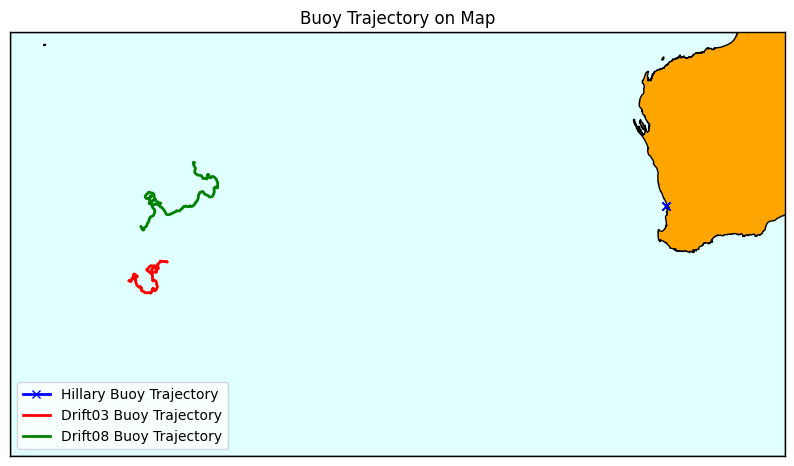

In [106]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

lon_h = np.concatenate([np.array(f_hillary.get('SpotData/lon')), np.array(f_hillary_2.get('SpotData/lon'))], axis=1)[0]
lat_h = np.concatenate([np.array(f_hillary.get('SpotData/lat')), np.array(f_hillary_2.get('SpotData/lat'))], axis=1)[0]
lon_d03 = np.concatenate([np.array(f_drift03.get('SpotData/lon')), np.array(f_drift03_2.get('SpotData/lon'))], axis=1)[0]
lat_d03 = np.concatenate([np.array(f_drift03.get('SpotData/lat')), np.array(f_drift03_2.get('SpotData/lat'))], axis=1)[0]
lon_d06 = np.concatenate([np.array(f_drift06.get('SpotData/lon')), np.array(f_drift06_2.get('SpotData/lon'))], axis=1)[0]
lat_d06 = np.concatenate([np.array(f_drift06.get('SpotData/lat')), np.array(f_drift06_2.get('SpotData/lat'))], axis=1)[0]


min_lat = np.min(np.concatenate([lat_h, lat_d03, lat_d06]))
max_lat = np.max(np.concatenate([lat_h, lat_d03, lat_d06]))
min_lon = np.min(np.concatenate([lon_h, lon_d03, lon_d06]))
max_lon = np.max(np.concatenate([lon_h, lon_d03, lon_d06]))

plt.figure(figsize=(10, 8))
m = Basemap(projection='merc',
            llcrnrlat=min_lat-10.0, urcrnrlat=max_lat+10.0,
            llcrnrlon=min_lon-10.0, urcrnrlon=max_lon+10.0,
            resolution='i')

m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='orange', lake_color='aqua')
m.drawmapboundary(fill_color='lightcyan')

x, y = m(lon_h, lat_h)
m.plot(x, y, marker='x', color='b', linewidth=2.0, label='Hillary Buoy Trajectory')
x, y = m(lon_d03, lat_d03)
m.plot(x, y, color='r', linewidth=2.0, label='Drift03 Buoy Trajectory')
x, y = m(lon_d06, lat_d06)
m.plot(x, y, color='g', linewidth=2.0, label='Drift08 Buoy Trajectory')
plt.title('Buoy Trajectory on Map')
plt.legend()
plt.savefig('/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/map.png')
plt.show()


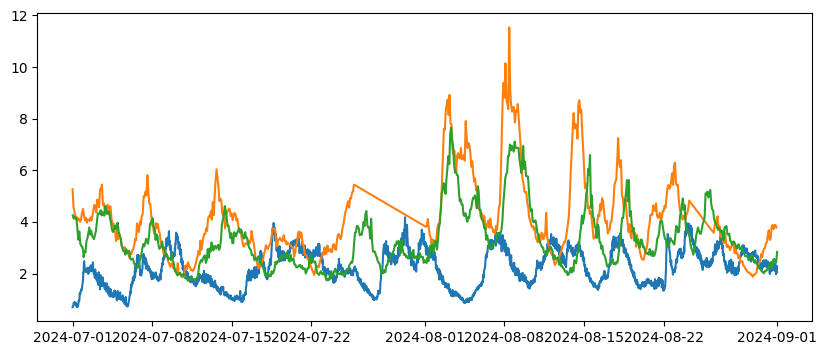

In [107]:
fig = plt.figure(figsize=(10,4))
plt.plot(data_time_hillarys, hs_h)
plt.plot(data_time_drift03, hs_d03)
plt.plot(data_time_drift06, hs_d06)

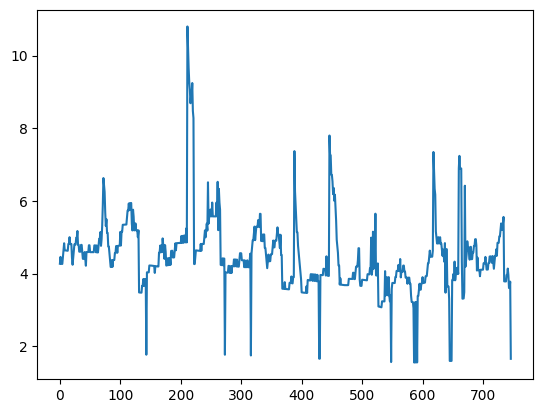

In [108]:
#Distance function
from math import radians, sin, cos, sqrt, asin


def distance_in_km(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return r * c


import numpy as np
from math import radians, sin, cos, sqrt, asin, pi


def wave_travel_time(freqs, dirs, spectrum, lon1, lat1, lon2, lat2):
    # 1. Find max frequency and its main direction
    idx_freq = np.argmax(np.sum(spectrum, axis=1))  # index of max energy frequency
    idx_dir = np.argmax(spectrum[idx_freq])  # index of max energy direction for that freq
    max_freq = freqs[idx_freq]
    main_dir = dirs[idx_dir] + 180  # degrees, oceanographic convention

    # 2. Calculate straight-line distance between points (Haversine)
    def haversine(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * asin(sqrt(a))
        r = 6371  # km
        return r * c

    dist = haversine(lon1, lat1, lon2, lat2)

    # 3. Compute wave speed (deep water Stokes wave approximation)
    g = 9.81  # m/s^2
    wave_speed = (g / (4 * pi * max_freq)) / 1000 * 3600  # km/h

    # 4. Compute travel time
    if wave_speed > 0:
        travel_time = abs(dist) / wave_speed  # seconds
        travel_time = travel_time / 24.0
    else:
        travel_time = np.nan

    return travel_time


trav_time_drift06 = np.array([wave_travel_time(freq, directions, d, lon, lat, lon_h[0], lat_h[0]) for d, lon, lat in
                              zip(data_drifting06, lon_d06, lat_d06)])
plt.plot(trav_time_drift06)

In [109]:
plot_sources=False
from hdpgpc.buoy_utils import plot_position_event_full, ordinal_float_to_datetime
if plot_sources:
    energy_point_estimate = []
    time_point_estimate = []
    plot = False
    #for i in range(0, 48, 6):
    for i in range(0, 24*60, 2):
        time_select_datetime = datetime(2024, 7, 1, 0) + timedelta(hours=i)
        print(time_select_datetime)
        fractional_day = (time_select_datetime.hour * 3600 + time_select_datetime.minute * 60 + time_select_datetime.second) / 86400.0
        time_select_ordinal = datetime.toordinal(time_select_datetime + timedelta(days = 366)) + fractional_day
        index_hillary = np.argmin(np.abs(spec_time_hillarys - time_select_ordinal))
        index_hillary_dp = np.argmin(np.abs(time_hillarys - time_select_ordinal))
        index_drift03 = np.argmin(np.abs(spec_time_drift03 - time_select_ordinal))
        index_drift03_dp = np.argmin(np.abs(time_drift03 - time_select_ordinal))
        index_drift06 = np.argmin(np.abs(spec_time_drift06 - time_select_ordinal))
        index_drift06_dp = np.argmin(np.abs(time_drift06 - time_select_ordinal))
        #time_select_datetime = datetime.fromordinal(int(time_select)) + timedelta(days=int(time_select%1)) - timedelta(days = 366)
        #time_select_datetime = time_select_datetime - timedelta(days=8)

        if plot:
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_drift03, directions, data_drifting03[index_drift03],
                                                    title='Drift 03 Buoy - Directional Spectrum of time '+ str(time_select_datetime))
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_drift06, directions, data_drifting06[index_drift06],
                                                    title='Drift 06 Buoy - Directional Spectrum of time '+ str(time_select_datetime))
            plt.show()

        hsig_h = np.concatenate([np.array(f_hillary.get('SpotData/hsig')), np.array(f_hillary_2.get('SpotData/hsig'))], axis=1)
        dp_h = np.concatenate([np.array(f_hillary.get('SpotData/dp')), np.array(f_hillary_2.get('SpotData/dp'))], axis=1)
        peak_freq_h = frequency_hillarys[np.argmax(np.sum(data[index_hillary], axis=1))]
        peak_energy_h = np.max(data[index_hillary])
        spread_h_ = np.concatenate([np.array(f_hillary.get('SpotData/directionalSpread')), np.array(f_hillary_2.get('SpotData/directionalSpread'))], axis=1)
        spread_h = spread_h_[np.argmax(np.sum(data[index_hillary], axis=1)), index_hillary_dp]

        freq__ = np.array(f_hillary.get('SpotData/frequency'))[:,0]

        hsig_d03 = np.concatenate([np.array(f_drift03.get('SpotData/hsig')), np.array(f_drift03_2.get('SpotData/hsig'))], axis=1)
        dp_d03 = np.concatenate([np.array(f_drift03.get('SpotData/dp')), np.array(f_drift03_2.get('SpotData/dp'))], axis=1)
        peak_freq_d03 = frequency_drift03[np.argmax(np.sum(data_drifting03[index_drift03], axis=1))]
        peak_energy_d03 = np.max(data_drifting03[index_drift03])
        spread_d03_ = np.concatenate([np.array(f_drift03.get('SpotData/directionalSpread')), np.array(f_drift03_2.get('SpotData/directionalSpread'))], axis=1)
        spread_d03 = spread_d03_[np.argmin(np.abs(freq__ - frequency_drift03[np.argmax(np.sum(data_drifting03[index_drift03], axis=1))].item())), index_drift03_dp]

        hsig_d08 = np.concatenate([np.array(f_drift06.get('SpotData/hsig')), np.array(f_drift06_2.get('SpotData/hsig'))], axis=1)
        dp_d08 = np.concatenate([np.array(f_drift06.get('SpotData/dp')), np.array(f_drift06_2.get('SpotData/dp'))], axis=1)
        peak_freq_d08 = frequency_drift06[np.argmax(np.sum(data_drifting06[index_drift06], axis=1))]
        peak_energy_d08 = np.max(data_drifting06[index_drift06])
        spread_d06_ = np.concatenate([np.array(f_drift06.get('SpotData/directionalSpread')), np.array(f_drift06_2.get('SpotData/directionalSpread'))], axis=1)
        spread_d06 = spread_d06_[np.argmin(np.abs(freq__ - frequency_drift06[np.argmax(np.sum(data_drifting06[index_drift06], axis=1))].item())), index_drift06_dp]

        time_d03 = ordinal_float_to_datetime(spec_time_drift03[0, index_drift03]) - timedelta(days=366)
        time_d08 = ordinal_float_to_datetime(spec_time_drift06[0, index_drift06]) - timedelta(days=366)

        obs_d03 = buoy_utils.BuoyObservation(lat_d03[index_drift03], lon_d03[index_drift03], time_d03, data_drifting03[index_drift03], peak_freq_d03, dp_d03[0,index_drift03_dp], peak_energy_d03, spread_d03)
        obs_d08 = buoy_utils.BuoyObservation(lat_d06[index_drift03], lon_d06[index_drift03], time_d08, data_drifting06[index_drift06], peak_freq_d08, dp_d08[0,index_drift06_dp], peak_energy_d08, spread_d06)

        triangulation = buoy_utils.SwellBackTriangulation(obs_d03, obs_d08, [lat_h[0], lon_h[0]])
        source = triangulation.triangulate_source_location(method='weighted_centroid')

        arrival = triangulation.predict_coastal_arrival(source)

        fractional_day_arrival = (arrival['arrival_time'].hour * 3600 + arrival['arrival_time'].minute * 60 + arrival['arrival_time'].second) / 86400.0
        time_arrival_ordinal = datetime.toordinal(arrival['arrival_time'] + timedelta(days = 366)) + fractional_day_arrival
        index_hillary_arrival = np.argmin(np.abs(spec_time_hillarys - time_arrival_ordinal))
        index_hillary_dp_arrival = np.argmin(np.abs(time_hillarys - time_arrival_ordinal))
        peak_freq_h_arrival = frequency_hillarys[np.argmax(np.sum(data[index_hillary_arrival], axis=1))]
        peak_energy_h_arrival = np.max(data[index_hillary_arrival])

        energy_point_estimate.append(arrival['arrival_energy'].item())
        time_point_estimate.append(arrival['arrival_time'])
        if plot:
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_hillarys, directions_hillarys, data_[index_hillary_arrival],
                                                    title='Hillary Buoy - Directional Spectrum of estimated arrival time '+ str(arrival['arrival_time']))

        b_lat_1 = np.array([c['lat'] for c in source['buoy1_backtrack']['all_candidates']]).squeeze()
        b_lon_1 = np.array([c['lon'] for c in source['buoy1_backtrack']['all_candidates']]).squeeze()

        b_lat_2 = np.array([c['lat'] for c in source['buoy2_backtrack']['all_candidates']]).squeeze()
        b_lon_2 = np.array([c['lon'] for c in source['buoy2_backtrack']['all_candidates']]).squeeze()

        min_lat = np.min(np.concatenate([lat_h, lat_d03, lat_d06, [source['source_lat']]]))#, b_lat_1, b_lat_2]))
        max_lat = np.max(np.concatenate([lat_h, lat_d03, lat_d06, [source['source_lat']]]))#, b_lat_1, b_lat_2]))
        min_lon = np.min(np.concatenate([lon_h, lon_d03, lon_d06, [source['source_lon']]]))#, b_lon_1, b_lon_2]))
        max_lon = np.max(np.concatenate([lon_h, lon_d03, lon_d06, [source['source_lon']]]))#, b_lon_1, b_lon_2]))

        min_lat, max_lat, min_lon, max_lon = -62, 0, 10, 125
        # Create figure with grid layout
        plot_position_event_full(source, arrival, (min_lat, max_lat), (min_lon, max_lon), peak_energy_h_arrival, peak_freq_h_arrival, dp_h,
                                 index_hillary_dp_arrival, time_select_datetime, lat_h, lon_h, lat_d03, lon_d03, lat_d06, lon_d06,
                                 index_drift03, index_drift06, index_hillary_arrival,
                                triangulation.DISPERSION_RATE,cluster_labels_d03, cluster_labels_d08, cluster_labels_h, b_lon_1, b_lat_1, b_lon_2, b_lat_2,
                                 title=f"prediction_source_centroid/Point source estimation for time {time_select_datetime}.")


    #%%
    fig = plt.figure(figsize=(15,4))
    ord_idx = np.argsort(time_point_estimate)
    #plt.scatter(np.array(time_point_estimate)[ord_idx], np.array(energy_point_estimate)[ord_idx], c='red', s=2.0, marker='x')
    plt.plot(np.array(time_point_estimate)[ord_idx], np.array(energy_point_estimate)[ord_idx]*0.2, c='red')
    plt.plot(data_time_hillarys, hs_h)
    plt.show()

In [113]:
from hdpgpc import buoy_utils
from datetime import datetime, timedelta
plot = False
energy_point_estimate = []
time_point_estimate = []

with open('arrival_estimations.txt', 'w') as f:
    for d in range(0, 24*60, 1):
        time_select_datetime = datetime(2024, 7, 1, 0) + timedelta(hours=d)
        fractional_day = (time_select_datetime.hour * 3600 + time_select_datetime.minute * 60 + time_select_datetime.second) / 86400.0
        time_select_ordinal = datetime.toordinal(time_select_datetime + timedelta(days = 366)) + fractional_day
        index_hillary = np.argmin(np.abs(spec_time_hillarys - time_select_ordinal))
        index_hillary_dp = np.argmin(np.abs(time_hillarys - time_select_ordinal))
        index_drift03 = np.argmin(np.abs(spec_time_drift03 - time_select_ordinal))
        index_drift03_dp = np.argmin(np.abs(time_drift03 - time_select_ordinal))
        index_drift06 = np.argmin(np.abs(spec_time_drift06 - time_select_ordinal))
        index_drift06_dp = np.argmin(np.abs(time_drift06 - time_select_ordinal))
        #time_select_datetime = datetime.fromordinal(int(time_select)) + timedelta(days=int(time_select%1)) - timedelta(days = 366)
        #time_select_datetime = time_select_datetime - timedelta(days=8)

        if plot:
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_drift03, directions, data_drifting03[index_drift03],
                                                    title='Drift 03 Buoy - Directional Spectrum of time '+ str(time_select_datetime))
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_drift06, directions, data_drifting06[index_drift06],
                                                    title='Drift 06 Buoy - Directional Spectrum of time '+ str(time_select_datetime))
            plt.show()

        freq__ = np.array(f_hillary.get('SpotData/frequency'))[:,0]

        hsig_h = np.concatenate([np.array(f_hillary.get('SpotData/hsig')), np.array(f_hillary_2.get('SpotData/hsig'))], axis=1)
        dp_h = np.concatenate([np.array(f_hillary.get('SpotData/dp')), np.array(f_hillary_2.get('SpotData/dp'))], axis=1)
        peak_freq_h = frequency_hillarys[np.argmax(np.sum(data[index_hillary], axis=1))]
        peak_energy_h = np.max(data[index_hillary])
        spread_h_ = np.concatenate([np.array(f_hillary.get('SpotData/directionalSpread')), np.array(f_hillary_2.get('SpotData/directionalSpread'))], axis=1)
        spread_h = spread_h_[np.argmin(np.abs(freq__ - frequency_hillarys[np.argmax(np.sum(data[index_hillary], axis=1))].item())), index_hillary_dp]

        hsig_d03 = np.concatenate([np.array(f_drift03.get('SpotData/hsig')), np.array(f_drift03_2.get('SpotData/hsig'))], axis=1)
        dp_d03 = np.concatenate([np.array(f_drift03.get('SpotData/dp')), np.array(f_drift03_2.get('SpotData/dp'))], axis=1)
        peak_freq_d03 = frequency_drift03[np.argmax(np.sum(data_drifting03[index_drift03], axis=1))]
        peak_energy_d03 = np.max(data_drifting03[index_drift03])
        spread_d03_ = np.concatenate([np.array(f_drift03.get('SpotData/directionalSpread')), np.array(f_drift03_2.get('SpotData/directionalSpread'))], axis=1)
        spread_d03 = spread_d03_[np.argmin(np.abs(freq__ - frequency_drift03[np.argmax(np.sum(data_drifting03[index_drift03], axis=1))].item())), index_drift03_dp]

        hsig_d08 = np.concatenate([np.array(f_drift06.get('SpotData/hsig')), np.array(f_drift06_2.get('SpotData/hsig'))], axis=1)
        dp_d08 = np.concatenate([np.array(f_drift06.get('SpotData/dp')), np.array(f_drift06_2.get('SpotData/dp'))], axis=1)
        peak_freq_d08 = frequency_drift06[np.argmax(np.sum(data_drifting06[index_drift06], axis=1))]
        peak_energy_d08 = np.max(data_drifting06[index_drift06])
        spread_d06_ = np.concatenate([np.array(f_drift06.get('SpotData/directionalSpread')), np.array(f_drift06_2.get('SpotData/directionalSpread'))], axis=1)
        spread_d06 = spread_d06_[np.argmin(np.abs(freq__ - frequency_drift06[np.argmax(np.sum(data_drifting06[index_drift06], axis=1))].item())), index_drift06_dp]

        time_d03 = matlab_datenum_to_datetime(spec_time_drift03[0, index_drift03])
        time_d08 = matlab_datenum_to_datetime(spec_time_drift06[0, index_drift06])

        obs_d03 = buoy_utils.BuoyObservation(lat_d03[index_drift03], lon_d03[index_drift03], time_d03, data_drifting03[index_drift03], peak_freq_d03, dp_d03[0,index_drift03_dp], peak_energy_d03, spread_d03)
        obs_d08 = buoy_utils.BuoyObservation(lat_d06[index_drift03], lon_d06[index_drift03], time_d08, data_drifting06[index_drift06], peak_freq_d08, dp_d08[0,index_drift06_dp], peak_energy_d08, spread_d06)

        triangulation = buoy_utils.SwellBackTriangulation(obs_d03, obs_d08, [lat_h[0], lon_h[0]])
        source = triangulation.triangulate_source_location(method='weighted_centroid')

        #source = triangulation.triangulate_source_location_bayesian(method='grid_search')

        arrival = triangulation.predict_coastal_arrival(source)

        fractional_day_arrival = (arrival['arrival_time'].hour * 3600 + arrival['arrival_time'].minute * 60 + arrival['arrival_time'].second) / 86400.0
        time_arrival_ordinal = datetime.toordinal(arrival['arrival_time'] + timedelta(days = 366)) + fractional_day_arrival
        index_hillary_arrival = np.argmin(np.abs(spec_time_hillarys - time_arrival_ordinal))
        index_hillary_dp_arrival = np.argmin(np.abs(time_hillarys - time_arrival_ordinal))
        peak_freq_h_arrival = frequency_hillarys[np.argmax(np.sum(data[index_hillary_arrival], axis=1))]
        peak_energy_h_arrival = np.max(data[index_hillary_arrival])

        energy_point_estimate.append(arrival['arrival_energy'].item())
        time_point_estimate.append(arrival['arrival_time'])

        if plot:
            fig, ax = buoy_utils.plot_directional_spectrum(frequency_hillarys, directions_hillarys, data_[index_hillary_arrival],
                                                    title='Hillary Buoy - Directional Spectrum of estimated arrival time '+ str(arrival['arrival_time']))

        print("\n-------Time event on drifts: " + str(time_select_datetime) + "--------", file=f)
        print("  Estimated time of source ", file=f)
        print("   " + str(arrival['source_generation_time']), file=f)
        print("  Arrival time and uncertainty", file=f)
        print("   " + str(arrival['arrival_time']), file=f)
        print("    --> Estimated spectral quantities:", file=f)
        print('        Estimated energy ' + str(arrival['arrival_energy'].item()) + ' vs real ' + str(peak_energy_h_arrival), file=f)
        print('        Estimated frequency ' + str(arrival['arrival_frequency']) + ' vs real ' + str(peak_freq_h_arrival), file=f)
        print('        Estimated direction '+ str(arrival['arrival_direction'].item()) + ' vs real ' + str(dp_h[:, index_hillary_dp_arrival].item()), file=f)

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 1.29 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 2.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 4.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 6.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 8.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 10.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc/buoy_utils.py:416: UserWarning:

Buoy observations are 12.37 hours apart

/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/hdpgpc

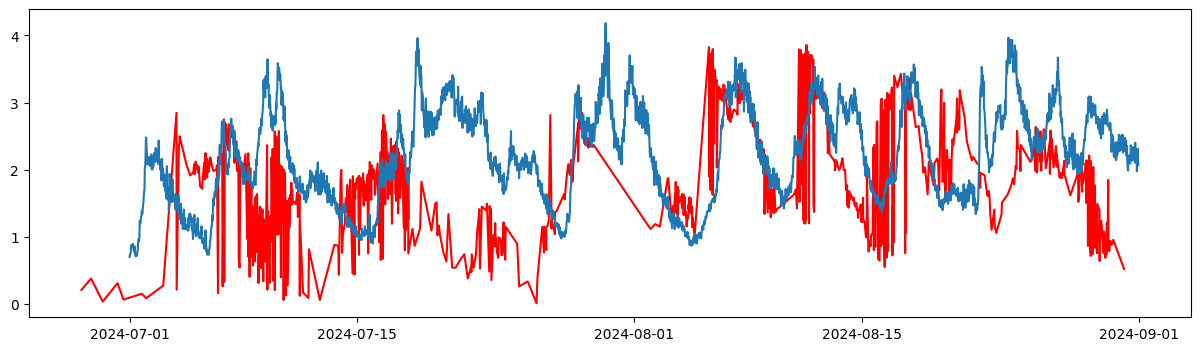

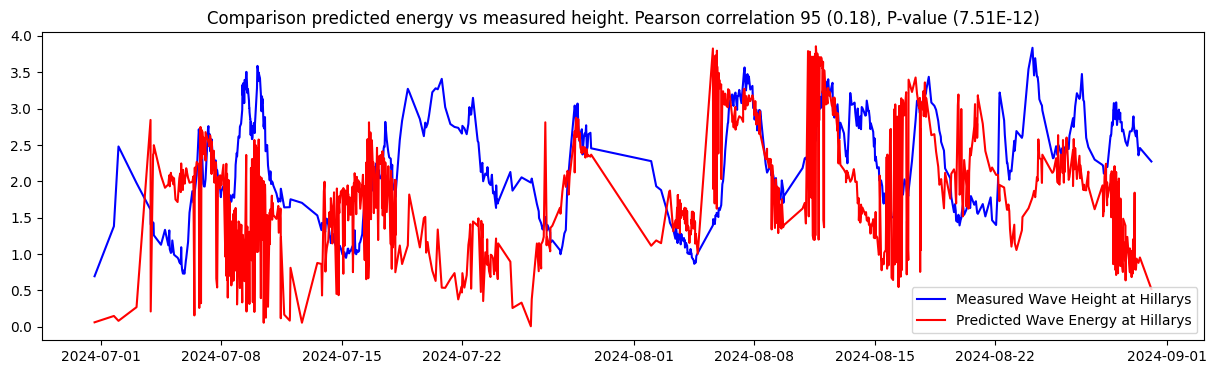

In [114]:
import pandas as pd
from scipy import stats

fig = plt.figure(figsize=(15,4))
ord_idx = np.argsort(time_point_estimate)
#plt.scatter(np.array(time_point_estimate)[ord_idx], np.array(energy_point_estimate)[ord_idx], c='red', s=2.0, marker='x')
plt.plot(np.array(time_point_estimate)[ord_idx], np.log(np.array(energy_point_estimate)[ord_idx]), c='red')
plt.plot(data_time_hillarys, hs_h)
plt.savefig("/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/plots/point_prediction_comparison.png")

measured_series = pd.Series(hs_h[:,0], index=data_time_hillarys)
predicted_series = pd.Series(np.array(energy_point_estimate)[ord_idx], index=np.array(time_point_estimate)[ord_idx])

tolerance = pd.Timedelta(hours=12)

aligned_measured = []
aligned_predicted = []
matched_times = []

for pred_time, pred_val in predicted_series.items():
    # Find measured observation within tolerance
    time_diffs = np.abs(measured_series.index - pred_time)
    min_diff_idx = time_diffs.argmin()
    min_diff = time_diffs[min_diff_idx]

    if min_diff <= tolerance:
        meas_time = measured_series.index[min_diff_idx]
        meas_val = measured_series.iloc[min_diff_idx]

        aligned_measured.append(meas_val)
        aligned_predicted.append(pred_val)
        matched_times.append(pred_time)

measured_clean = np.array(aligned_measured)
predicted_clean = np.array(aligned_predicted)
matched_times = np.array(matched_times)
r, p_value = stats.pearsonr(measured_clean, predicted_clean)

plt.figure(figsize=(15,4))
plt.plot(matched_times, measured_clean, c='blue', label='Measured Wave Height at Hillarys')
plt.plot(matched_times, np.log(predicted_clean), c='red', label='Predicted Wave Energy at Hillarys')
plt.title(f"Comparison predicted energy vs measured height. Pearson correlation 95 ({r:.2f}), P-value ({p_value:.2E})")
plt.legend()
plt.savefig("/home/adrian.perez/Documents/OceanWave/HDP-GPC/hdpgpc/ocean/plots/point_prediction_comparison_axisXsampled.png")


---